<a href="https://colab.research.google.com/github/mp-codez/probability-statistics-experiments/blob/solution/Central_Limit_Theorem_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
train_titanic_url = "https://github.com/mp-codez/dataset/blob/main/titanic/train.csv?raw=true"
test_titanic_url = "https://github.com/mp-codez/dataset/blob/main/titanic/test.csv?raw=true"

In [2]:
import numpy as np
import pandas as pd

In [6]:
train_df = pd.read_csv(train_titanic_url) # having servived column
test_df = pd.read_csv(test_titanic_url)   # dont have servived column

In [11]:
df = pd.concat([train_df.drop(columns=['Survived']), test_df]).sample(1309)  # we are using here sample to suffle the data and so order of the rows will changed


In [12]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
283,1175,3,"Touma, Miss. Maria Youssef",female,9.0,1,1,2650,15.2458,NaN,C
175,1067,2,"Brown, Miss. Edith Eileen",female,15.0,0,2,29750,39.0000,NaN,S
21,22,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
579,580,3,"Jussila, Mr. Eiriik",male,32.0,0,0,STON/O 2. 3101286,7.9250,NaN,S
42,934,3,"Goldsmith, Mr. Nathan",male,41.0,0,0,SOTON/O.Q. 3101263,7.8500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
181,182,2,"Pernot, Mr. Rene",male,NaN,0,0,SC/PARIS 2131,15.0500,NaN,C
613,614,3,"Horgan, Mr. John",male,NaN,0,0,370377,7.7500,NaN,Q
291,1183,3,"Daly, Miss. Margaret Marcella Maggie""""",female,30.0,0,0,382650,6.9500,NaN,Q


<Axes: ylabel='Density'>

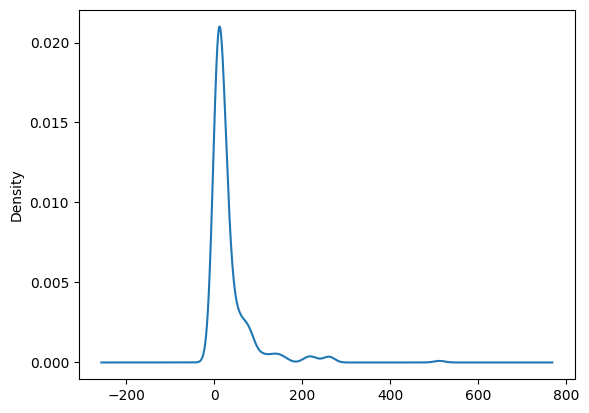

In [13]:
df['Fare'].plot(kind='kde')

In [34]:
# sample size = 50 -> 100 times
samples = []

for i in range(100):
  samples.append(df['Fare'].dropna().sample(50).values.tolist())

In [35]:
samples = np.array(samples)

In [36]:
sampling_means = samples.mean(axis=1)

In [37]:
import seaborn as sns

<Axes: ylabel='Density'>

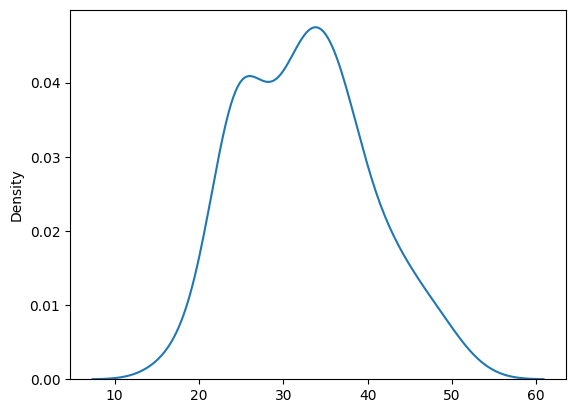

In [38]:
sns.kdeplot(sampling_means)

In [39]:
sampling_means.mean()

np.float64(32.584714600000005)

In [41]:
sampling_means.std()/np.sqrt(50)

np.float64(1.0605556676433536)

In [42]:
lower_limit = sampling_means.mean() - 2*(sampling_means.std()/np.sqrt(50))
upper_limit = sampling_means.mean() + 2*(sampling_means.std()/np.sqrt(50))

In [43]:
print("The range is", lower_limit, '-', upper_limit)

The range is 30.4636032647133 - 34.70582593528671


In [44]:
df['Fare'].mean()

np.float64(33.295479281345564)